**Ex 1 - Location and monitoring of aquifers (Darcy flow)**

In [ ]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*
import numpy as np
import matplotlib.pyplot as plt
import gdown
clc()

# Mesh and data download

In [ ]:
gdown.download(id = "1cPcWium7XTJqd828r0mxZpaghl6DRfQj", output = "terrain_mesh.xml", quiet = False)
gdown.download(id = "1rhAqgdJWDZthXN2ly3QQGYxfVyxsytoL", output = "terrain_simulations.npz", quiet = False)

mesh = fe.loadmesh("terrain_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)
clc()

dataset = np.load("terrain_simulations.npz")
mu, u = dataset["mu"], dataset["u"]

mu.shape, u.shape

((200, 3), (200, 1577))

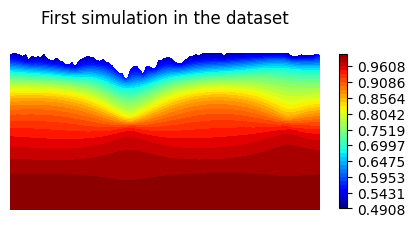

In [ ]:
plt.figure(figsize = (5, 5))
fe.plot(u[0], Vh, levels = 40, colorbar = True, shrink = 0.4)
plt.title("First simulation in the dataset\n")
None

# Split the data in two batches

In [ ]:
# 150 simulations for training-validation
# 50 simulations for testing

mu, u = dv.tensor(dataset['mu']), dv.tensor(dataset['u'])

N = u.shape[0]
Nh = u.shape[1]
p = mu.shape[1]

print("Simulations:\t%d." % N)
print("FOM dimension:\t%d." % Nh)
print("Parameters:\t%d." % p)

Ntrain = 150
Ntest = N - Ntrain

utrain = u[:Ntrain]
utest = u[Ntrain:]
mutrain = mu[:Ntrain]
mutest = mu[Ntrain:]

Simulations:	200.
FOM dimension:	1577.
Parameters:	3.


In [ ]:
utrain.shape, utest.shape, mutrain.shape, mutest.shape

(torch.Size([150, 1577]),
 torch.Size([50, 1577]),
 torch.Size([150, 3]),
 torch.Size([50, 3]))

# Evaluation of the singular values trend

In [ ]:
from scipy.linalg import svd
X, s, Yt = svd(utrain.T.cpu().numpy(), full_matrices = False) # computation of the singular value decomposition

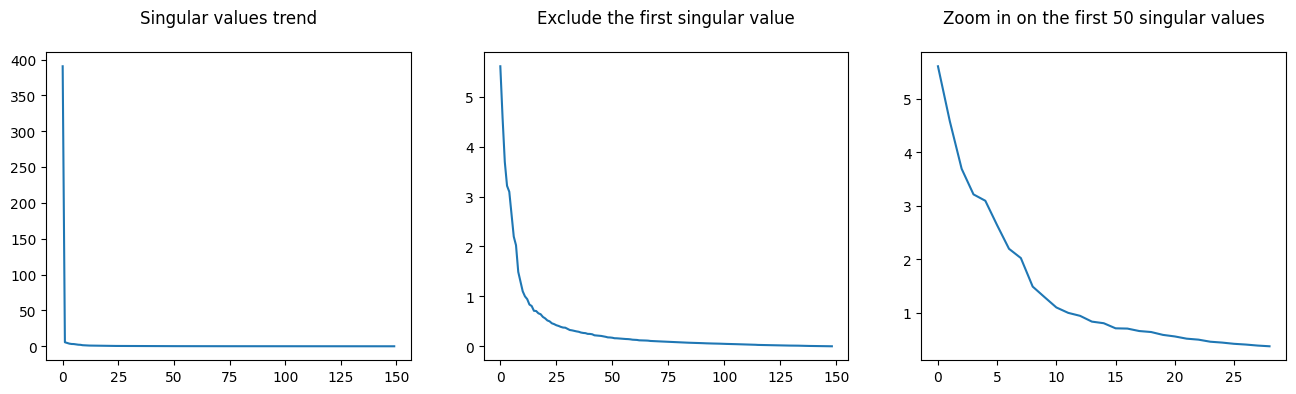

In [ ]:
plt.figure(figsize = (16, 4))
plt.subplot(1, 3, 1)
plt.plot(s)
plt.title("Singular values trend\n")
plt.subplot(1, 3, 2)
plt.plot(s[1:150])
plt.title("Exclude the first singular value\n")
plt.subplot(1, 3, 3)
plt.plot(s[1:30])
plt.title("Zoom in on the first 50 singular values\n")
plt.show()

In [ ]:
X.shape, s.shape, Yt.shape

((1577, 150), (150,), (150, 150))

In [ ]:
# Evaluation of the energy lost when truncating to define the latent dimension
print('Energy lost by truncation of basis:')

for r in [7, 8, 9, 10, 15, 20, 30, 50]:
    pod_err = np.sqrt(np.sum(s[r:]**2)/np.sum(s**2))
    print(r, num2p(pod_err))

Energy lost by truncation of basis:
7 1.24%
8 1.10%
9 0.97%
10 0.90%
15 0.67%
20 0.53%
30 0.37%
50 0.20%


In [ ]:
# Selection of the latent dimension
latent = 15

In [ ]:
# Function: compute the error between the solution predicted by the network and the solution of the FOM problem
l2 = L2(Vh)
l2.cuda()
clc()

def error(utrue, upred):
  return (l2(utrue - upred) / l2(utrue)).mean()

# DL-ROM approach

START NNs training

In [ ]:
# # Definition and training of the autoencoder
# rho_e = lambda x: relu(x) - 10*relu(-x)
# rho_d = lambda x: relu(x) - 0.1*relu(-x)

# encoder = Dense(Nh, 50, rho_e) + Dense(50, latent, rho_e)
# decoder = Dense(latent, 50, rho_d) + Dense(50, 100, rho_d) + Dense(100, Nh, activation = None)

# autoencoder = DFNN(encoder + decoder)
# autoencoder.He()
# autoencoder.cuda()

# autoencoder.train(u, u, ntrain = Ntrain, epochs = 300, loss = mse(l2), error = error, notation = '%')
# autoencoder.freeze()

		Train	Test
Epoch 300:	0.89%	1.02%.

>> ETA: 0.26s.


Training complete. Elapsed time: 1 minutes 18.68 seconds.


In [ ]:
# # Computation of the ROM coefficients
# cDL = encoder(u)
# cDL.shape

torch.Size([200, 15])

In [ ]:
# # Definition and training of the NN that learns the map from the parameter space to the ROM solution space
# phi_dl = DFNN(Dense(p, 50, gelu) + Dense(50, 200, gelu) + Dense(200, 200, gelu) + Dense(200, 80, gelu) + Dense(80, latent, activation = None))

# phi_dl.He()
# phi_dl.cuda()
# phi_dl.train(mu, cDL, ntrain = Ntrain, epochs = 300, loss = mse(euclidean), notation = '%')
# phi_dl.freeze()

		Train	Test
Epoch 300:	346.17%	1274.69%.

>> ETA: 0.29s.


Training complete. Elapsed time: 1 minutes 27.48 seconds.


In [ ]:
# # Save the trained NNs
# autoencoder.save("autoencoder.npz")
# phi_dl.save("phi_dl.npz")

FINISH NNs training

In [ ]:
# Redefine the architectures of the NNs and load the trained NNs
rho_e = lambda x: relu(x) - 10*relu(-x)
rho_d = lambda x: relu(x) - 0.1*relu(-x)

encoder = Dense(Nh, 50, rho_e) + Dense(50, latent, rho_e)
decoder = Dense(latent, 50, rho_d) + Dense(50, 100, rho_d) + Dense(100, Nh, activation = None)

autoencoder = DFNN(encoder + decoder)
autoencoder.He()
autoencoder.cuda()

autoencoder.load("autoencoder.npz")
autoencoder.freeze()

phi_dl = DFNN(Dense(p, 50, gelu) + Dense(50, 200, gelu) +Dense(200, 200, gelu) + Dense(200, 80, gelu) + Dense(80, latent, activation = None))

phi_dl.He()
phi_dl.cuda()

phi_dl.load("phi_dl.npz")
phi_dl.freeze()

In [ ]:
# Analysis of the error of the identity map learned by the autoencoder
print("Autoencoder MRE: %s" % num2p(error(utest, autoencoder(utest))))

Autoencoder MRE: 1.02%


In [ ]:
# Analysing the error of the DL-ROM NN
dlrom = lambda x: decoder(phi_dl(x))

print("Average relative error of DL-ROM: %s" % num2p(error(utest, dlrom(mutest))))

Average relative error of DL-ROM: 1.23%


# POD-NN approah

In [ ]:
# Compute POD basis
V = dv.tensor(X[: , :latent])

# Computing the FOM solution using the identity matrix
uproj = u @ V @ V.T # uproj --> same dimension of u (200 x 1577)

avg_proj_err = error(utest, uproj[Ntrain:])
print("Average projection error: %s" % (num2p(avg_proj_err)))

Average projection error: 0.64%


START NN training

In [ ]:
# # Compute the ROM coefficients
# cPOD = u @ V
# cPOD.shape

torch.Size([200, 15])

In [ ]:
# # Define and train the NN that learns the map from the parameter space to the ROM solution space
# phi_pod = DFNN(Dense(p, 50, gelu) + Dense(50, 100, gelu) + Dense(100, 200, gelu) + Dense(200, 100, gelu) + Dense(100, 50, gelu) + Dense(50, latent, activation = None))
# phi_pod.He()
# phi_pod.cuda()
# phi_pod.train(mu, cPOD, ntrain = Ntrain, epochs = 300, loss = mse(euclidean), notation = '%')
# phi_pod.freeze()

		Train	Test
Epoch 300:	0.83%	3.89%.

>> ETA: 0.30s.


Training complete. Elapsed time: 1 minutes 30.29 seconds.


In [ ]:
# # Save the NN
# phi_pod.save("phi_pod.npz")

FINISH NN training

In [ ]:
# Redefine the architecture of the NN and load the trained NN
phi_pod = DFNN(Dense(p, 50, gelu) + Dense(50, 100, gelu) + Dense(100, 200, gelu) + Dense(200, 100, gelu) + Dense(100, 50, gelu) + Dense(50, latent, activation = None))
phi_pod.He()
phi_pod.cuda()

phi_pod.load("phi_pod.npz")
phi_pod.freeze()

In [ ]:
# Analysing the error of the POD-NN
podnn = lambda x: phi_pod(x) @ V.T

print("Average relative error of POD-NN: %s" % num2p(error(utest, podnn(mutest))))

Average relative error of POD-NN: 0.77%


# Selection of POD-NN approach

Considerations on why DL-ROM has been discarded:

*   SVD shows a rapid decay (only the first value has a difference of 2 orders of magnitude compared to the others)
*   POD basis already captures the solution very efficiently
*   For a 3-parameter elliptic problem, POD coefficients are usually much smoother functions of (γ, α, β) than autoencoder latent coordinates








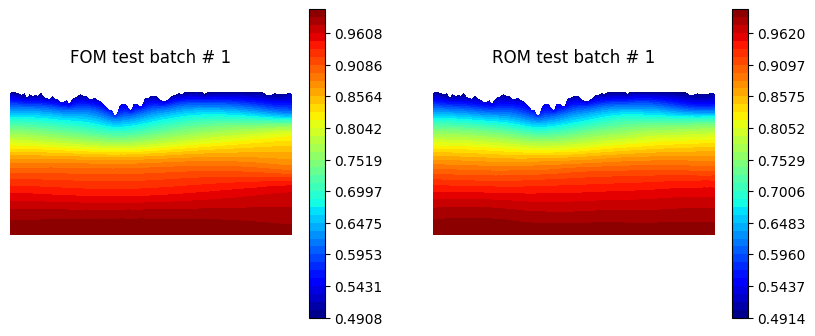

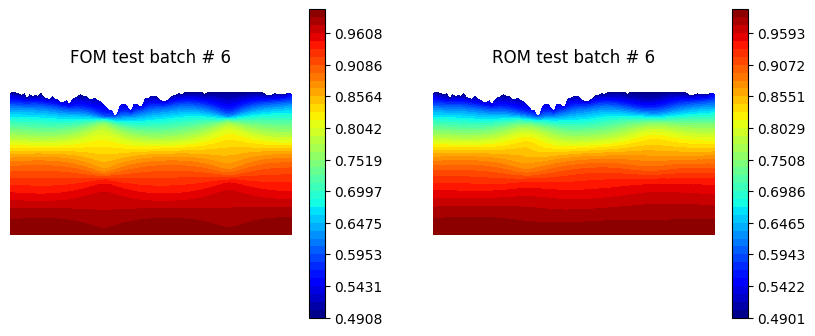

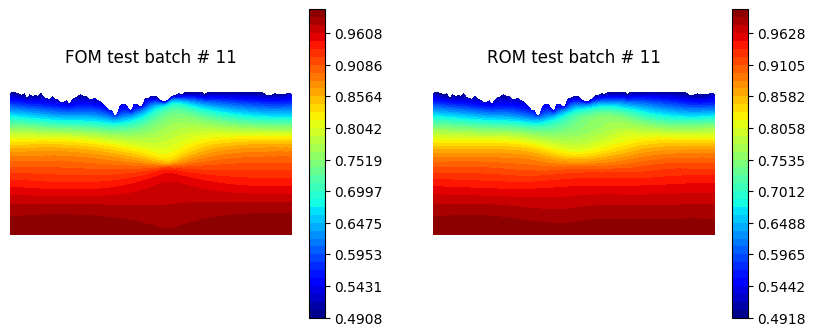

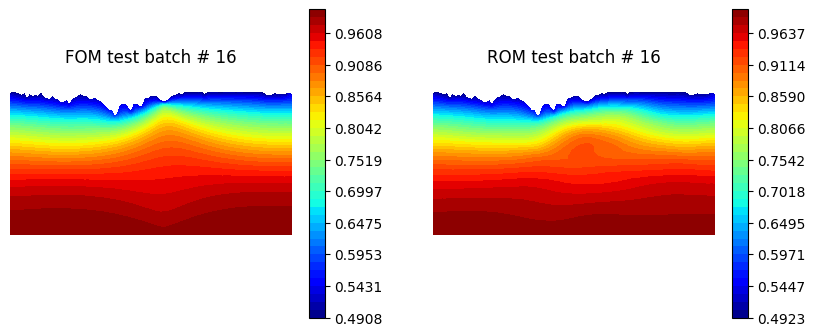

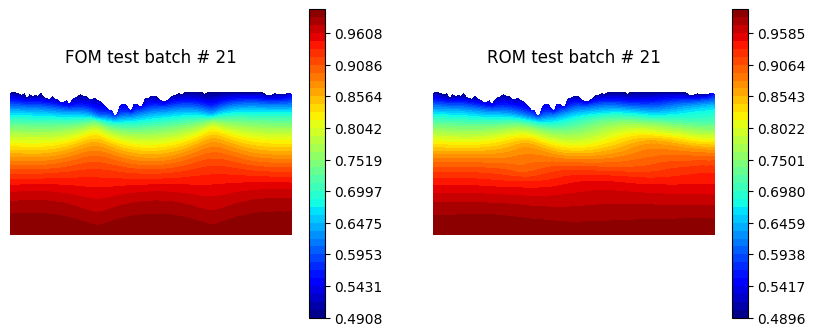

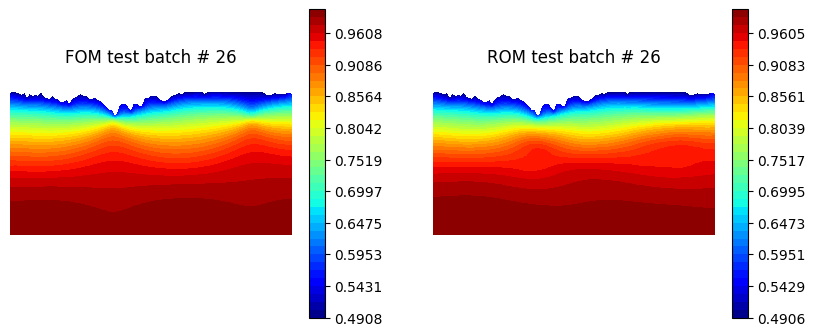

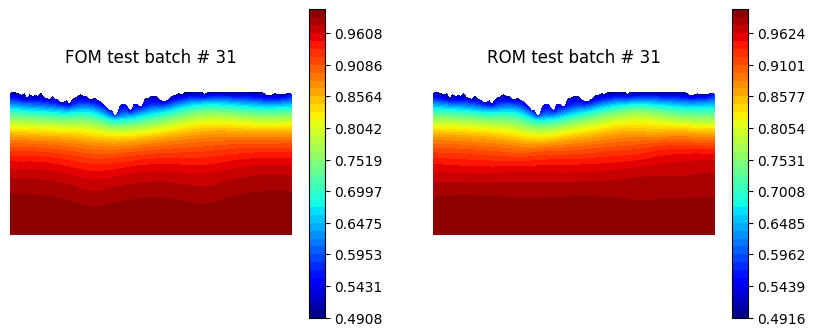

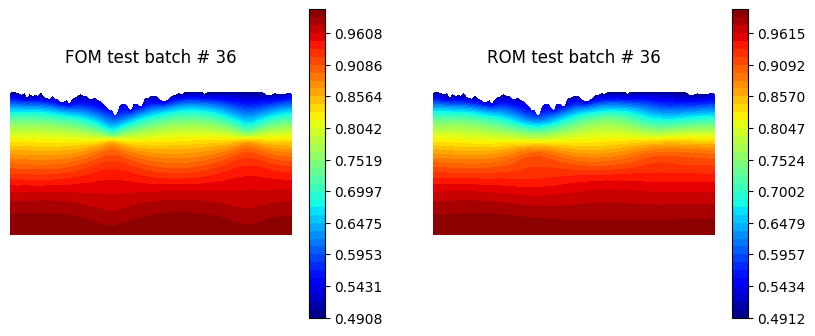

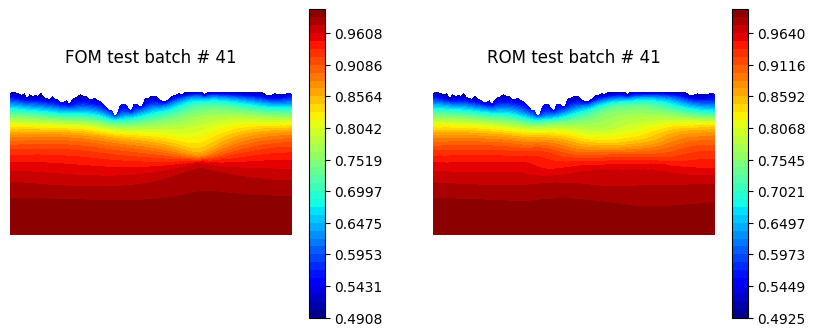

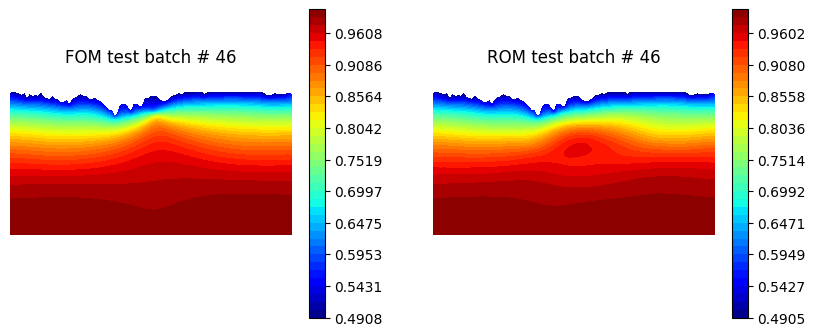

In [ ]:
# Visual comparison between FOM and ROM solutions
for i in range(0, Ntest, 5):
  plt.figure(figsize = (10, 10))
  plt.subplot(1, 2, 1)
  fe.plot(utest[i], Vh, levels = 40, colorbar = True, shrink = 0.4)
  plt.title(f"FOM test batch # {i+1}\n")
  plt.subplot(1, 2, 2)
  fe.plot(podnn(mutest[i].unsqueeze(0))[0], Vh, levels = 40, colorbar = True, shrink = 0.4)
  plt.title(f"ROM test batch # {i+1}\n")
  None

# Computational time of the ROM:

In [ ]:
# Example
gamma = np.random.uniform(5, 10)
alpha = np.random.uniform(4, 16)
beta  = np.random.uniform(4, 16)

mu0 = dv.tensor([[gamma, alpha, beta]])

print("gamma = ", gamma)
print("alpha = ", alpha)
print("beta = ", beta)

gamma =  8.523809870687359
alpha =  12.152659100509343
beta =  5.352912540892142


FOM simulation time: 0.1 s
DL-ROM simulation time: 0.002 s
Time gained with DL-ROM: 0.098 s
Time gained in percentage: 98 %


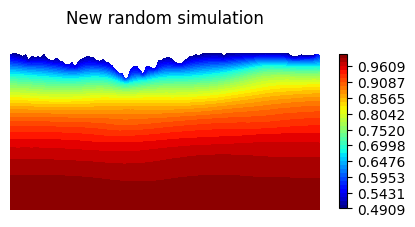

In [ ]:
# Computation of the time
from time import perf_counter

t0 = perf_counter()
u_rom = podnn(mu0)
t1 = perf_counter()

plt.figure(figsize = (5, 5))
fe.plot(u_rom[0], Vh, levels = 40, colorbar = True, shrink = 0.4)
plt.title("New random simulation\n")
None

Tfom = 0.1

print("FOM simulation time: %.1f s" % Tfom)
print("DL-ROM simulation time: %.3f s" % (t1-t0))

Tgain = 0.1 - (t1-t0)
Tgain_p = Tgain / Tfom

print("Time gained with DL-ROM: %.3f s" % Tgain)
print("Time gained in percentage: %.f %%" % (Tgain_p*100))

# Calculation of Tmax(u(μ)):

In [ ]:
# Aquifer maximum thickness computation
def aquifer_maxthickness(u0):
  band = fe.dofs(Vh)[(u0 > 0.7) * (u0 < 0.85)]
  x0, h = np.linspace(0, 1, 100), mesh.hmax()
  bools = (band[:, 0].reshape(-1, 1) <= x0.reshape(1, -1) + h/2) * (band[:, 0].reshape(-1, 1) >= x0.reshape(1, -1) - h/2)
  y_at_x0 = band[:, 1].reshape(-1, 1) * bools
  ymax_at_x0 = y_at_x0.max(axis = 0)
  y_at_x0[y_at_x0 == 0] = np.inf
  ymin_at_x0 = y_at_x0.min(axis = 0)
  return (ymax_at_x0 - ymin_at_x0).max()

In [ ]:
# Define the function that given the parameter values returns an approximation of Tmax:
def ROMassemble(gamma, alpha, beta):
  mu0 = dv.tensor([[gamma, alpha, beta]])
  u_rom = podnn(mu0)

  return aquifer_maxthickness(u_rom[0].cpu())

In [ ]:
# Define the parameter values and calculate Tmax
gamma0 = 10
alpha0 = 8.2
beta_vect = np.linspace(4, 16, 121)

Tmax = np.zeros(len(beta_vect))

for i in range(len(beta_vect)):
  Tmax[i] = ROMassemble(gamma, alpha, beta_vect[i])

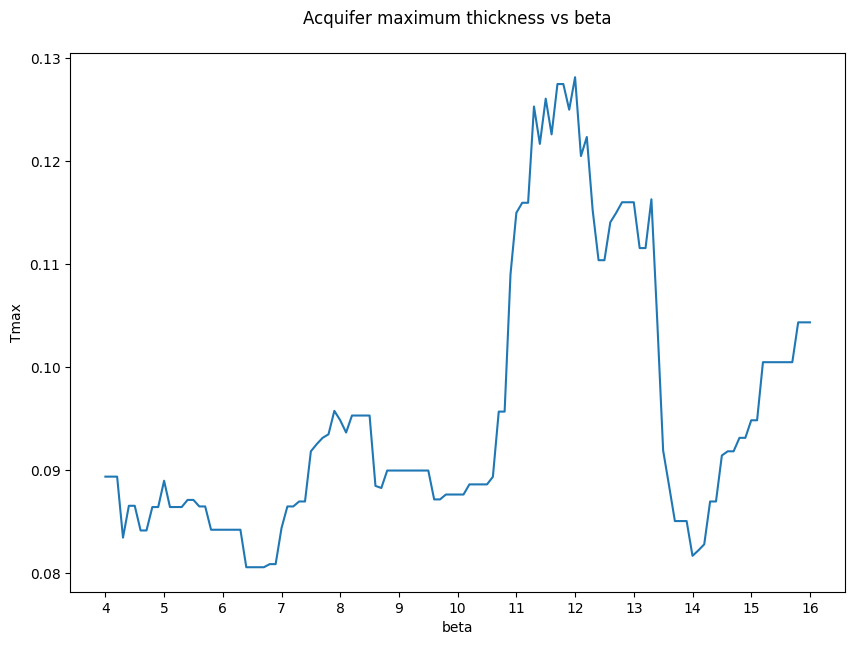

In [ ]:
# Plot of Tmax vs beta
plt.figure(figsize = (10, 7))
plt.plot(beta_vect, Tmax, '-')
plt.xticks(beta_vect[::10])
plt.xlabel("beta")
plt.ylabel("Tmax")
plt.title("Acquifer maximum thickness vs beta\n")
None

In [ ]:
Tmax_max = np.max(Tmax)
beta_max = beta_vect[np.argmax(Tmax)]
u_rom_max = podnn(dv.tensor([[gamma0, alpha0, beta_max]]))

print("The acquifer maximum thickness of %.3f is obtained by beta equal to %.2f" % (Tmax_max, beta_max))

The acquifer maximum thickness of 0.128 is obtained by beta equal to 12.00


In [ ]:
# Aquifer plot
import torch
from dlroms.minns import Interpolate

Dh = fe.space(mesh, 'DG', 0)
clc()

interpolator = Interpolate(mesh, Vh, Dh)
interpolator.to(dv)

def aquifer_plot(u0):
  u0t = u0 if isinstance(u0, torch.Tensor) else dv.tensor(u0)
  acquifer = interpolator((((u0t>0.7)*(u0t<0.85)*1.0)).reshape(1, -1))[0]
  fe.plot(acquifer, Dh, cmap = 'YlOrBr_r')
  plt.title("Acquifer profile\n")

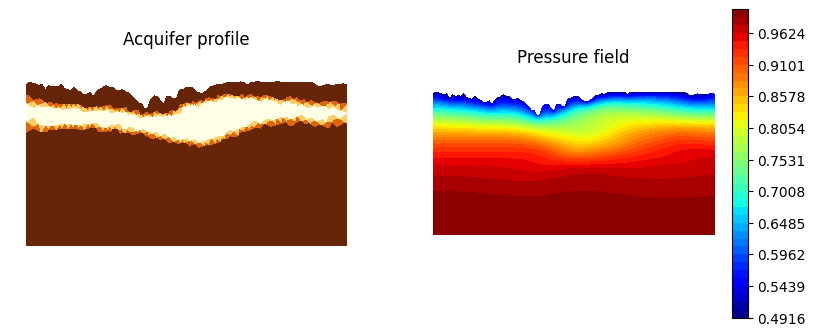

In [ ]:
# Plot acquifer profile with maximum thickness
plt.figure(figsize = (10, 10))
plt.subplot(1, 2, 1)
aquifer_plot(u_rom_max[0])
plt.subplot(1, 2, 2)
fe.plot(u_rom_max[0], Vh, levels = 40, colorbar = True, shrink = 0.4)
plt.title("Pressure field\n")
None